# BRATS SE Model Suite — Full Code

All seven 3D tumour-segmentation models are defined here in a single notebook.  
Models 1–5 share the same **encoder / decoder skeleton** (`BaseUNet3D`) and swap only the **attention block**.  
Models 6–7 are plain baselines (no attention) using the same skeleton.

| # | Model | Attention / Block type |
|---|-------|------------------------|
| 1 | `SE-UNet` | Classic SE block (channel recalibration) |
| 2 | `SE-ResUNet` | SE block inside residual conv blocks |
| 3 | `Modality-Adaptive SE-UNet` | Modality-conditioned SE + uncertainty-gated fusion |
| 4 | `Hierarchical ST SE-UNet` | Multi-scale SE with growth-prior conditioning (FiLM) |
| 5 | `Graph SE-UNet` | SE-recalibrated grid-graph with hand-rolled GAT message passing |
| 6 | `Basic UNet3D` | No attention — plain Conv-BN-ReLU blocks |
| 7 | `Basic ResUNet3D` | No attention — residual Conv-BN-ReLU blocks |
| 8 | `Graph SE-ResUNet` | SE-recalibrated grid-graph GAT + residual conv blocks |

---
**Layout:**
1. Imports & device setup
2. Shared building blocks — `conv_blocks.py`
3. Attention blocks (3.1 Classic SE · 3.2 Modality-Adaptive · 3.3 Hierarchical FiLM · 3.4 Graph GAT)
4. Base U-Net skeleton — `base_unet.py`
5. Model factories — 5.1–5.5 SE variants · 5.6 Basic UNet3D · 5.7 Basic ResUNet3D
6. Smoke-test — dummy forward pass for every modelu

In [1]:
# ============================================================
# SECTION 0 — Dependencies
# ============================================================
!python -c "import monai" || pip install -q "monai-weekly[nibabel, tqdm]"
!python -c "import matplotlib" || pip install -q matplotlib
%matplotlib inline

Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'monai'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.5 MB/s eta 0:00:0000:010:01


In [2]:
# ============================================================
# SECTION 1 — Imports & Configuration
# ============================================================
# Standard Library Imports
import os
import gc
import time
import glob
import copy
import math
import csv
from pathlib import Path
from dataclasses import dataclass, fields, asdict
from typing import List, Tuple

# Numerical & Data Science
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.signal import fftconvolve
from tqdm.auto import tqdm

# PyTorch Core
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.fft
from torch.utils.data import DataLoader

# PyTorch Vision & Specialized Ops
from torchvision.ops import DeformConv2d

# MONAI (Medical Imaging Framework)
import monai
from monai.config import print_config
from monai.data import SmartCacheDataset, decollate_batch
from monai.inferers import sliding_window_inference
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.transforms import (
    Activations,
    AsDiscrete,
    Compose,
    CenterSpatialCropd,
    EnsureChannelFirstd,
    EnsureTyped,
    LoadImaged,
    MapTransform,
    NormalizeIntensityd,
    RandFlipd,
    RandScaleIntensityd,
    RandShiftIntensityd,
)

# Optional/External (Commented out as in original)
# import torch_scatter
# import torch_sparse as ts

print_config()

MONAI version: 1.7.dev2632
Numpy version: 2.0.2
Pytorch version: 2.10.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 5a454eec9f1b95c6e263b40f7d237f1fdf8f654c
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.5.4
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.4.2
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.20.0
gdown version: 5.2.2
TorchVision version: 0.25.0+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.3.3
einops version: 0.8.2
transformers version: 5.0.0
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://monai.readthedocs.io/en/latest/installati

In [3]:
# --- Config ---
DATASET_PATH        = Path("/kaggle/input/datasets/anirbanulkasemi/brats2021-16/BraTS2021_16")
SAVE_PATH           = "/kaggle/working/best_model.pth"
SELECTED_MODALITIES = ["t1", "t2", "t1ce", "flair"]
ROI_SIZE            = (128, 128, 64)
INITIAL_FILTERS     = 16
BATCH_SIZE          = 2
NUM_WORKERS         = 4
CACHE_RATE          = 1
CACHE_NUM           = 100
MAX_EPOCHS          = 100
VAL_INTERVAL        = 1
VAL_AMP             = True
DEVICE              = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_LABELS        = ["TC", "WT", "ET"]

# ── Model Selection ──────────────────────────────────────────────────────────
# Set MODEL_NAME to one of the 9 available architectures:
#   "se_unet"              → Classic SE U-Net (channel recalibration)
#   "se_resunet"           → SE inside residual conv blocks
#   "modality_adaptive_se" → Modality-conditioned SE + uncertainty gating
#   "hierarchical_st_se"   → Multi-scale SE with FiLM growth-prior conditioning
#   "graph_se"             → SE-recalibrated grid-graph with hand-rolled GAT
#   "basic_unet3d"         → Baseline plain UNet3D (no attention)
#   "basic_resunet3d"      → Baseline residual UNet3D (no attention)
#   "graph_se_resunet"     → Graph SE block with residual conv blocks (GAT + ResConv)
#   "graph_se_resunet_fused" → Fused GraphSE-ResBlock (single block/level, idea-v1.md)
MODEL_NAME = "graph_se_resunet_fused"  # ← change here to switch model

print(f"Device    : {DEVICE}")
print(f"Model     : {MODEL_NAME}")

Device    : cuda
Model     : graph_se_resunet_fused


In [4]:
# ============================================================
# SECTION 2 — Data Preparation
# ============================================================

def build_data_list(base_paths, seg_paths, modalities):
    """Build list of {image: [mod_paths...], label: seg_path} dicts."""
    return [
        {
            "image": [str(p).replace("t1ce.npy", f"{m}.npy") for m in modalities],
            "label": str(seg_paths[i]),
        }
        for i, p in enumerate(base_paths)
    ]


image_files = sorted(glob.glob(f"{DATASET_PATH}/*/*t1ce.npy"))
seg_files   = sorted(glob.glob(f"{DATASET_PATH}/*/*seg.npy"))
print(f"Total samples: {len(image_files)}")

train_imgs, val_imgs, train_segs, val_segs = train_test_split(
    image_files, seg_files, test_size=0.2, random_state=42
)
train_data = build_data_list(train_imgs, train_segs, SELECTED_MODALITIES)
val_data   = build_data_list(val_imgs,   val_segs,   SELECTED_MODALITIES)
print(f"Train: {len(train_data)}  |  Val: {len(val_data)}")

Total samples: 1251
Train: 1000  |  Val: 251


In [5]:
# ============================================================
# SECTION 3 -- Transforms
# ============================================================

class ConvertBraTSLabels(MapTransform):
    """
    Decomposes the integer segmentation map into 3 binary channels:
      ch0 = TC  (Tumor Core):    labels 1 & 4
      ch1 = WT  (Whole Tumor):   labels 1, 2 & 4
      ch2 = ET  (Enhancing):     label 4 only
    """
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            lbl = d[key]
            if lbl.ndim == 4:
                lbl = lbl.squeeze(0)
            tc = (lbl == 1) | (lbl == 4)
            wt = tc | (lbl == 2)
            et = lbl == 4
            d[key] = torch.stack([tc, wt, et], dim=0).float()
        return d


from monai.transforms import RandRotate90d, RandGaussianNoised, RandAdjustContrastd

_shared = [
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys="image"),
    EnsureTyped(keys=["image", "label"]),
    ConvertBraTSLabels(keys="label"),
    CenterSpatialCropd(keys=["image", "label"], roi_size=ROI_SIZE),
    # FIX: channel_wise=True so each modality (T1/T2/T1ce/FLAIR) is
    # normalised independently -- they have completely different intensity ranges.
    # Old channel_wise=False normalised all 4 channels together, distorting
    # the per-modality statistics that ModalityAdaptiveSE relies on.
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
]

train_transform = Compose(_shared + [
    # FIX: flip along all three spatial axes (was only axis=0 before)
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    RandRotate90d(keys=["image", "label"], prob=0.3, spatial_axes=(0, 1)),
    RandScaleIntensityd(keys="image", factors=0.1, prob=0.5),
    RandShiftIntensityd(keys="image", offsets=0.1, prob=0.5),
    RandGaussianNoised(keys="image", prob=0.2, std=0.05),
    RandAdjustContrastd(keys="image", prob=0.2, gamma=(0.8, 1.2)),
])

val_transform = Compose(_shared)

In [6]:
# ============================================================
# SECTION 4 -- Datasets & Dataloaders
# ============================================================
from monai.data import CacheDataset

train_ds = SmartCacheDataset(
    data=train_data, transform=train_transform,
    replace_rate=0.3, cache_rate=CACHE_RATE, cache_num=CACHE_NUM,
)

val_ds = CacheDataset(
    data=val_data, transform=val_transform,
    cache_rate=CACHE_RATE, cache_num=len(val_data),
)

# Added pin_memory=True to speed up CPU-GPU tensor transfers
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=1,          shuffle=False, num_workers=0, pin_memory=True)

# Quick shape check
_b = next(iter(train_loader))
print(f"Image batch: {_b['image'].shape}  |  Label batch: {_b['label'].shape}")
del _b
gc.collect()
torch.cuda.empty_cache()

Loading dataset: 100%|██████████| 251/251 [05:24<00:00,  1.29s/it]


Image batch: torch.Size([2, 4, 128, 128, 64])  |  Label batch: torch.Size([2, 3, 128, 128, 64])


---
## 1 · Imports & Device Setup

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from typing import Callable, List

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


---
## 2 · Shared Conv Building Blocks
> Source: `src/blocks/conv_blocks.py`
>
> All models import from here — no conv logic lives in model files.

In [8]:
"""Conv building blocks for 3D U-Net encoder/decoder.

All models import from here -- no conv logic lives in model files.
"""


class ConvBlock3D(nn.Module):
    """Conv-BN-ReLU x 2."""

    def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.0):
        super().__init__()
        layers = [
            nn.Conv3d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.insert(3, nn.Dropout3d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class ResConvBlock3D(nn.Module):
    """Residual Conv-BN-ReLU x 2 with 1x1 skip projection."""

    def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.0):
        super().__init__()
        layers = [
            nn.Conv3d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_channels),
        ]
        if dropout > 0:
            layers.insert(3, nn.Dropout3d(dropout))
        self.block = nn.Sequential(*layers)
        self.skip = (
            nn.Sequential(
                nn.Conv3d(in_channels, out_channels, 1, bias=False),
                nn.BatchNorm3d(out_channels),
            )
            if in_channels != out_channels
            else nn.Identity()
        )
        self.act = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.act(self.block(x) + self.skip(x))


def build_conv_block(block_type: str, in_ch: int, out_ch: int, dropout: float = 0.0):
    if block_type == "residual":
        return ResConvBlock3D(in_ch, out_ch, dropout)
    return ConvBlock3D(in_ch, out_ch, dropout)


class DownBlock(nn.Module):
    """Max-pool 2x -> conv block."""

    def __init__(self, in_channels: int, out_channels: int, block_type: str = "conv", dropout: float = 0.0):
        super().__init__()
        self.pool = nn.MaxPool3d(2)
        self.conv = build_conv_block(block_type, in_channels, out_channels, dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(self.pool(x))


class UpBlock(nn.Module):
    """Trilinear upsample 2x -> concat skip -> conv block."""

    def __init__(self, in_channels: int, skip_channels: int, out_channels: int, block_type: str = "conv", dropout: float = 0.0):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.conv = build_conv_block(block_type, in_channels + skip_channels, out_channels, dropout)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        # FIX: compare only spatial dims (x.shape[2:] vs skip.shape[2:]).
        # Old check (x.shape != skip.shape) was ALWAYS True because x and skip
        # have different channel counts by design, triggering a redundant
        # interpolate call on every single forward pass even when spatial
        # dims already match -- wasted compute every step.
        if x.shape[2:] != skip.shape[2:]:
            x = nn.functional.interpolate(x, size=skip.shape[2:], mode="trilinear", align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))


print("Conv building blocks defined: ConvBlock3D, ResConvBlock3D, DownBlock, UpBlock")

Conv building blocks defined: ConvBlock3D, ResConvBlock3D, DownBlock, UpBlock


---
## 3 · Attention Blocks

### 3.1 Classic SE Block
> Source: `src/blocks/se_basic.py`
>
> Used by **Model 1** (SE-UNet) and **Model 2** (SE-ResUNet)

In [9]:
"""Classic Squeeze-and-Excitation block for 3D feature maps."""


class SEBlock3D(nn.Module):
    """Global avg pool -> FC-reduce -> ReLU -> FC-expand -> sigmoid -> channel scale."""

    def __init__(self, channels: int, reduction_ratio: int = 16):
        super().__init__()
        reduced = max(1, channels // reduction_ratio)
        self.squeeze = nn.AdaptiveAvgPool3d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, reduced, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(reduced, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor, **kwargs) -> torch.Tensor:
        b, c, *_ = x.shape
        scale = self.squeeze(x).view(b, c)
        scale = self.excitation(scale).view(b, c, 1, 1, 1)
        return x * scale


print("SEBlock3D defined")



# import torch
# import torch.nn as nn


# class SEBlock3D(nn.Module):
#     """Global avg pool -> FC-reduce -> SiLU -> FC-expand -> sigmoid -> channel scale."""

#     def __init__(self, channels: int, reduction_ratio: int = 16):
#         super().__init__()
#         reduced = max(1, channels // reduction_ratio)
#         self.squeeze = nn.AdaptiveAvgPool3d(1)
#         self.excitation = nn.Sequential(
#             nn.Linear(channels, reduced, bias=False),
#             nn.SiLU(inplace=True),
#             nn.Linear(reduced, channels, bias=False),
#             nn.Sigmoid(),
#         )

#     def forward(self, x: torch.Tensor, **kwargs) -> torch.Tensor:
#         b, c, *_ = x.shape
#         scale = self.squeeze(x).view(b, c)
#         scale = self.excitation(scale).view(b, c, 1, 1, 1)
#         return x * scale


# print("SEBlock3D defined")

SEBlock3D defined


### 3.2 Modality-Adaptive SE Block
> Source: `src/blocks/se_modality_adaptive.py`
>
> Used by **Model 3** (Modality-Adaptive SE-UNet)

Receives per-modality confidence `modality_conf` (B, n_modalities) and fuses it with per-channel statistics via a small MLP. Uncertainty is estimated from the std of the per-modality confidences and used as a gating scalar that attenuates the learned excitation when the model is uncertain about which modalities are reliable.

In [10]:
"""Modality-Adaptive SE block with corrected uncertainty gating.

FIX -- Uncertainty gate (two bugs in old version):

Bug A -- Inverted direction:
  Old: gate = exp(-std(softmax_conf))
  When softmax is concentrated on one modality (certain), std is HIGH -> gate LOW.
  When softmax is uniform (uncertain), std is 0 -> gate = 1.0 (full trust).
  This PENALISES certainty and REWARDS uncertainty -- the opposite of intent.

Bug B -- Negligible range:
  std of a 4-element probability vector that sums to 1 spans [0, 0.433].
  So exp(-std) spans [0.649, 1.0] -- only a 35% dynamic range.

Fix -- Entropy-based gate with correct direction:
  Entropy = 0    when model is certain  (one modality dominates) -> gate = 1.0
  Entropy = max  when uncertain (uniform dist)                   -> gate = 0.5
  Range: [0.5, 1.0] -- wider and correct direction.
"""


class ModalityAdaptiveSE(nn.Module):
    def __init__(self, channels: int, n_modalities: int = 4, reduction_ratio: int = 16, dropout: float = 0.2):
        super().__init__()
        reduced = max(1, channels // reduction_ratio)
        self._n_modalities = n_modalities

        # channel squeeze path
        self.squeeze = nn.AdaptiveAvgPool3d(1)

        # conditioning MLP: channel stats + modality_conf -> excitation weights
        in_dim = channels + n_modalities
        self.cond_mlp = nn.Sequential(
            nn.Linear(in_dim, reduced, bias=False),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(reduced, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor, modality_conf: torch.Tensor = None, **kwargs) -> torch.Tensor:
        b, c, *_ = x.shape
        ch_stats = self.squeeze(x).view(b, c)   # (B, C)

        if modality_conf is None:
            modality_conf = torch.ones(b, self._n_modalities, device=x.device, dtype=x.dtype) / self._n_modalities

        # FIX: entropy-based uncertainty gate with correct direction.
        # Entropy is 0 when model is certain (one modality dominates),
        # and log(n_modalities) when fully uncertain (uniform distribution).
        eps = 1e-8
        entropy = -(modality_conf * (modality_conf + eps).log()).sum(dim=-1, keepdim=True)  # (B, 1)
        max_entropy = math.log(self._n_modalities)       # log(4) ~= 1.386
        normalised_uncertainty = entropy / max_entropy   # 0 = certain, 1 = uncertain

        # gate: 1.0 when certain (low entropy), 0.5 when maximally uncertain
        gate = 1.0 - 0.5 * normalised_uncertainty        # (B, 1), range [0.5, 1.0]

        feat = torch.cat([ch_stats, modality_conf], dim=-1)       # (B, C + n_mod)
        excitation = self.cond_mlp(feat).view(b, c, 1, 1, 1)
        return x * excitation * gate.view(b, 1, 1, 1, 1)


class UncertaintyHead(nn.Module):
    """MC-dropout epistemic uncertainty via N stochastic forward passes.

    Kept as a standalone head so the base model forward path does not branch.
    Call estimate(model_forward_fn, x, n_passes) after training to get
    per-voxel uncertainty maps.
    """

    def __init__(self, dropout: float = 0.2):
        super().__init__()
        self.dropout = dropout

    @staticmethod
    def estimate(forward_fn, x: torch.Tensor, n_passes: int = 5) -> torch.Tensor:
        """Run n_passes stochastic forward passes; return voxel-wise std across passes."""
        preds = torch.stack([forward_fn(x) for _ in range(n_passes)], dim=0)  # (P, B, C, H, W, D)
        probs = torch.softmax(preds, dim=2)
        return probs.std(dim=0)  # (B, C, H, W, D)


print("ModalityAdaptiveSE (fixed entropy gate) and UncertaintyHead defined")

ModalityAdaptiveSE (fixed entropy gate) and UncertaintyHead defined


### 3.3 Hierarchical Spatio-Temporal SE Block with FiLM Conditioning
> Source: `src/blocks/se_hierarchical.py`
>
> Used by **Model 4** (Hierarchical ST SE-UNet)

Squeezes a feature map at multiple spatial resolutions, concatenates the pooled vectors, then applies FiLM (Feature-wise Linear Modulation) conditioned on a growth-prior vector before producing per-channel excitation weights.  
FiLM conditioning: `h = gamma(z) * squeeze_features + beta(z)`

In [11]:
"""Hierarchical Spatio-Temporal SE block with FiLM growth-prior conditioning.

FIX -- _multiscale_squeeze was a no-op multi-scale:

Old (buggy):
    p = F.adaptive_avg_pool3d(x, scale).flatten(2).mean(-1)   # (B, C)
For scale > 1 this pools to (B, C, s, s, s), flattens spatial to (B, C, s^3),
then takes mean over s^3 -> (B, C). But averaging the averages of disjoint
non-overlapping partitions equals the global average. So ALL scales produced
the SAME (B, C) global average vector. The concat was 3 identical copies.

Fixed:
    p = F.adaptive_avg_pool3d(x, scale).flatten(1)            # (B, C * s^3)
Spatial structure is preserved. Each of the s^3 pooled cells contributes
a separate C-dim feature, giving richer multi-resolution context.
  scale=1 -> (B, 1*C)
  scale=2 -> (B, 8*C)
  scale=4 -> (B, 64*C)  [memory note: for bottleneck C=256 this is 16384 dims]

Memory-safe recommendation for Kaggle: use pool_scales=(1, 2) -> 9*C total.
"""


class GrowthPriorEncoder(nn.Module):
    """Encodes a growth-prior scalar/vector into a fixed-dim conditioning embedding."""

    def __init__(self, prior_dim: int, embed_dim: int = 32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(prior_dim, embed_dim),
            nn.ReLU(inplace=True),
            nn.Linear(embed_dim, embed_dim),
        )

    def forward(self, growth_prior: torch.Tensor) -> torch.Tensor:
        return self.encoder(growth_prior)


class HierarchicalSTSEBlock(nn.Module):
    def __init__(
        self,
        channels: int,
        growth_prior_dim: int = 4,
        film_hidden_dim: int = 32,
        pool_scales: tuple = (1, 2),   # NOTE: default changed to (1,2) for memory safety
        reduction_ratio: int = 16,
    ):
        super().__init__()
        self.pool_scales = pool_scales
        reduced = max(1, channels // reduction_ratio)

        # FIX: total_pool_dim = sum(s^3 * C) -- preserves spatial structure
        # pool_scales=(1,2)  -> (1+8)*C   =  9*C  [memory safe]
        # pool_scales=(1,2,4)-> (1+8+64)*C= 73*C  [use only if VRAM allows]
        total_pool_dim = sum(s ** 3 for s in pool_scales) * channels
        self.squeeze_reduce = nn.Linear(total_pool_dim, reduced, bias=False)

        # FiLM generator: growth_prior_embed -> (gamma, beta) for the reduced space
        self.prior_enc  = GrowthPriorEncoder(growth_prior_dim, film_hidden_dim)
        self.film_gamma = nn.Linear(film_hidden_dim, reduced)
        self.film_beta  = nn.Linear(film_hidden_dim, reduced)

        # excitation head
        self.excitation = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Linear(reduced, channels, bias=False),
            nn.Sigmoid(),
        )

    def _multiscale_squeeze(self, x: torch.Tensor) -> torch.Tensor:
        pooled = []
        for scale in self.pool_scales:
            # FIX: flatten(1) preserves all s^3 pooled cells as separate features.
            # Do NOT take .mean(-1) -- that collapses everything back to global avg.
            p = F.adaptive_avg_pool3d(x, scale).flatten(1)   # (B, C * scale^3)
            pooled.append(p)
        return torch.cat(pooled, dim=-1)   # (B, total_pool_dim)

    def forward(self, x: torch.Tensor, growth_prior: torch.Tensor = None, **kwargs) -> torch.Tensor:
        b, c, *_ = x.shape

        if growth_prior is None:
            growth_prior = torch.zeros(b, 4, device=x.device, dtype=x.dtype)

        ms_feat = self._multiscale_squeeze(x)       # (B, total_pool_dim)
        h = self.squeeze_reduce(ms_feat)             # (B, reduced)

        # FiLM modulation: affine transform conditioned on growth prior
        z     = self.prior_enc(growth_prior)         # (B, film_hidden)
        gamma = self.film_gamma(z)                   # (B, reduced)
        beta  = self.film_beta(z)                    # (B, reduced)
        h = gamma * h + beta                         # element-wise FiLM

        excitation = self.excitation(h).view(b, c, 1, 1, 1)
        return x * excitation


print("GrowthPriorEncoder and HierarchicalSTSEBlock (fixed multi-scale squeeze) defined")

GrowthPriorEncoder and HierarchicalSTSEBlock (fixed multi-scale squeeze) defined


### 3.4 Graph SE Block — Grid-Graph with Hand-Rolled GAT
> Source: `src/blocks/se_graph.py`
>
> Used by **Model 5** (Graph SE-UNet)

No `torch_geometric` dependency — graph adjacency and attention are computed inline.

**Architecture:**
1. `SuperpixelGraphBuilder` divides the 3D feature map into a regular coarse grid. Each node = average of voxels in one grid cell. Edges = 6-connectivity (face-adjacent cells in 3D).
2. `GraphSEBlock`: build graph → SE-recalibrate per-node features → one GAT layer (attention logits: `concat(h_i, h_j) → linear → LeakyReLU → softmax`) → broadcast node features back to voxel grid → multiply by sigmoid gate.

In [12]:
class SuperpixelGraphBuilder:
    """Builds a regular-grid graph from a 3D feature map.

    Edge list is vectorized (no per-node Python loop) and cached per
    (grid_shape, device) since it's static across forward calls.
    """

    def __init__(self, node_stride: int = 8):
        self.node_stride = node_stride
        self._edge_cache = {}  # (gH, gW, gD, device) -> (src_idx, dst_idx)

    def build(self, x: torch.Tensor):
        b, c, h, w, d = x.shape
        gH = max(1, math.ceil(h / self.node_stride))
        gW = max(1, math.ceil(w / self.node_stride))
        gD = max(1, math.ceil(d / self.node_stride))

        pooled = F.adaptive_avg_pool3d(x, (gH, gW, gD))
        node_feats = pooled.flatten(2).transpose(1, 2)  # (B, N, C)

        key = (gH, gW, gD, x.device)
        if key not in self._edge_cache:
            self._edge_cache[key] = self._grid_edges(gH, gW, gD, x.device)
        src_idx, dst_idx = self._edge_cache[key]

        return node_feats, (src_idx, dst_idx), (gH, gW, gD)

    @staticmethod
    def _grid_edges(gH, gW, gD, device):
        """6-connected + self-loop edge list, built with vectorized ops.

        Loop is over the 7 fixed offsets, not over N nodes -- O(1) Python
        iterations regardless of grid size. Never materializes a dense
        N x N adjacency matrix, so it stays cheap even at fine strides.
        """
        N = gH * gW * gD
        idx = torch.arange(N, device=device)
        iz = idx // (gW * gD)
        iy = (idx % (gW * gD)) // gD
        ix = idx % gD

        offsets = [(0, 0, 0), (1, 0, 0), (-1, 0, 0),
                   (0, 1, 0), (0, -1, 0), (0, 0, 1), (0, 0, -1)]

        src_list, dst_list = [], []
        for dz, dy, dx in offsets:
            nz, ny, nx = iz + dz, iy + dy, ix + dx
            valid = (nz >= 0) & (nz < gH) & (ny >= 0) & (ny < gW) & (nx >= 0) & (nx < gD)
            nidx = nz * gW * gD + ny * gD + nx
            src_list.append(idx[valid])
            dst_list.append(nidx[valid])

        return torch.cat(src_list), torch.cat(dst_list)


class GraphSEBlock(nn.Module):
    def __init__(self, channels: int, node_stride: int = 4, gat_heads: int = 4,
                 gat_hidden: int = 64, reduction_ratio: int = 16):
        super().__init__()
        self.builder = SuperpixelGraphBuilder(node_stride)
        self.channels = channels
        self.gat_heads = gat_heads
        self.gat_hidden = gat_hidden
        reduced = max(1, channels // reduction_ratio)

        self.node_se = nn.Sequential(
            nn.Linear(channels, reduced),
            nn.ReLU(inplace=True),
            nn.Linear(reduced, channels),
            nn.Sigmoid(),
        )

        self.gat_attn = nn.Linear(2 * channels, gat_heads, bias=False)
        self.gat_val = nn.Linear(channels, gat_hidden * gat_heads, bias=False)
        self.gat_out = nn.Linear(gat_hidden * gat_heads, channels, bias=False)
        # matches the actual input dim of gat_attn (2*channels), not gat_hidden
        self._attn_scale = math.sqrt(2 * channels)

        self.gate = nn.Sequential(
            nn.Linear(channels, channels),
            nn.Sigmoid(),
        )

    def forward_prev(self, x: torch.Tensor, **kwargs) -> torch.Tensor:
        b, c, h, w, d = x.shape
        node_feats, (src_idx, dst_idx), (gH, gW, gD) = self.builder.build(x)
        N = gH * gW * gD

        se_scale = self.node_se(node_feats)
        node_feats = node_feats * se_scale

        values = self.gat_val(node_feats).view(b, N, self.gat_heads, self.gat_hidden)

        h_src = node_feats[:, src_idx, :]
        h_dst = node_feats[:, dst_idx, :]

        attn_logits = self.gat_attn(torch.cat([h_src, h_dst], dim=-1)) / self._attn_scale
        attn_logits = F.leaky_relu(attn_logits, 0.2)

        attn_logits_exp = torch.exp(attn_logits - attn_logits.max(dim=1, keepdim=True).values)
        denom = torch.zeros(b, N, self.gat_heads, device=x.device, dtype=attn_logits_exp.dtype)
        denom.index_add_(1, dst_idx, attn_logits_exp)
        denom = denom.clamp(min=1e-9)
        attn_weights = attn_logits_exp / denom[:, dst_idx, :]
        
        v_src = values[:, src_idx, :, :]
        weighted = v_src * attn_weights.unsqueeze(-1)
        agg = torch.zeros(b, N, self.gat_heads, self.gat_hidden, device=x.device, dtype=weighted.dtype)
        agg.index_add_(1, dst_idx, weighted)
        agg = agg.view(b, N, self.gat_heads * self.gat_hidden)
        agg = self.gat_out(agg)

        # residual around the GAT layer to prevent oversmoothing
        node_out = F.leaky_relu(agg + node_feats, 0.2)

        excitation = self.gate(node_out)

        excitation_grid = excitation.transpose(1, 2).view(b, c, gH, gW, gD)
        excitation_up = F.interpolate(excitation_grid, size=(h, w, d), mode="trilinear", align_corners=False)

        return x * excitation_up


    def forward(self, x: torch.Tensor, **kwargs) -> torch.Tensor:
        b, c, h, w, d = x.shape
        node_feats, (src_idx, dst_idx), (gH, gW, gD) = self.builder.build(x)
        N = gH * gW * gD
        
        se_scale = self.node_se(node_feats)
        node_feats = node_feats * se_scale
        
        values = self.gat_val(node_feats).view(b, N, self.gat_heads, self.gat_hidden)
        h_src = node_feats[:, src_idx, :]
        h_dst = node_feats[:, dst_idx, :]
        
        # 1. Compute Raw Attention Logits
        attn_logits = self.gat_attn(torch.cat([h_src, h_dst], dim=-1)) / self._attn_scale
        attn_logits = F.leaky_relu(attn_logits, 0.2)
        
        # 2. Compute Numerators
        attn_logits_exp = torch.exp(attn_logits - attn_logits.max(dim=1, keepdim=True).values)
        
        # --- [SAFE TO DELETE] ---
        del h_src, h_dst, attn_logits  # Not needed anymore
        # ------------------------

        # 3. Compute Denominator
        denom = torch.zeros(b, N, self.gat_heads, device=x.device, dtype=attn_logits_exp.dtype)
        denom.index_add_(1, dst_idx, attn_logits_exp)
        denom = denom.clamp(min=1e-9)
        
        # 4. Compute Final Softmax Weights
        attn_weights = attn_logits_exp / denom[:, dst_idx, :]
        
        # --- [SAFE TO DELETE] ---
        del attn_logits_exp, denom  # Not needed anymore
        # ------------------------

        # 5. Message Aggregation
        v_src = values[:, src_idx, :, :]
        weighted = v_src * attn_weights.unsqueeze(-1)
        
        agg = torch.zeros(b, N, self.gat_heads, self.gat_hidden, device=x.device, dtype=weighted.dtype)
        agg.index_add_(1, dst_idx, weighted)
        
        # --- [SAFE TO DELETE] ---
        del weighted, attn_weights, v_src  # Free up spatial activation maps
        # ------------------------

        agg = agg.view(b, N, self.gat_heads * self.gat_hidden)
        agg = self.gat_out(agg)
        
        node_out = F.leaky_relu(agg + node_feats, 0.2)
        excitation = self.gate(node_out)
        
        excitation_grid = excitation.transpose(1, 2).view(b, c, gH, gW, gD)
        excitation_up = F.interpolate(excitation_grid, size=(h, w, d), mode="trilinear", align_corners=False)
        
        return x * excitation_up

---
## 4 · Base U-Net Skeleton
> Source: `src/models/base_unet.py`
>
> All 5 models use this class unchanged; only `attention_block_factory` differs.
> No attention logic lives here — this file only wires conv blocks and skip connections.

In [13]:
"""BaseUNet3D -- shared encoder/decoder skeleton.

All 5 models use this class unchanged; only `attention_block_factory` differs.
No attention logic lives here -- this file only wires conv blocks and skip connections.
"""


class BaseUNet3D(nn.Module):
    """
    Args:
        in_channels:              input image channels (4 for BRATS)
        out_channels:             segmentation classes
        features:                 channel sizes per encoder level
        block_type:               "conv" or "residual"
        attention_block_factory:  callable(channels) -> nn.Module
                                  The returned module's forward signature must be
                                  forward(x, **cond) -> x (same shape).
        extra_forward_kwargs:     if True, forward() accepts **cond and passes it
                                  through to every attention block call.
        dropout:                  dropout rate inside conv blocks
    """

    def __init__(
        self,
        in_channels: int = 4,
        out_channels: int = 4,
        features: List[int] = None,
        block_type: str = "conv",
        attention_block_factory: Callable = None,
        extra_forward_kwargs: bool = False,
        dropout: float = 0.0,
    ):
        super().__init__()
        features = features or [32, 64, 128, 256]
        self.extra_forward_kwargs = extra_forward_kwargs

        if attention_block_factory is None:
            attention_block_factory = lambda c: nn.Identity()

        # encoder
        self.enc0 = build_conv_block(block_type, in_channels, features[0], dropout)
        self.enc0_att = attention_block_factory(features[0])
        self.down1 = DownBlock(features[0], features[1], block_type, dropout)
        self.down1_att = attention_block_factory(features[1])
        self.down2 = DownBlock(features[1], features[2], block_type, dropout)
        self.down2_att = attention_block_factory(features[2])
        self.down3 = DownBlock(features[2], features[3], block_type, dropout)
        self.down3_att = attention_block_factory(features[3])

        # bottleneck
        self.bottleneck = build_conv_block(block_type, features[3], features[3] * 2, dropout)
        self.bottleneck_att = attention_block_factory(features[3] * 2)

        # decoder
        self.up3 = UpBlock(features[3] * 2, features[3], features[3], block_type, dropout)
        self.up3_att = attention_block_factory(features[3])
        self.up2 = UpBlock(features[3], features[2], features[2], block_type, dropout)
        self.up2_att = attention_block_factory(features[2])
        self.up1 = UpBlock(features[2], features[1], features[1], block_type, dropout)
        self.up1_att = attention_block_factory(features[1])
        self.up0 = UpBlock(features[1], features[0], features[0], block_type, dropout)
        self.up0_att = attention_block_factory(features[0])

        # segmentation head
        self.head = nn.Conv3d(features[0], out_channels, 1)

    def forward(self, x: torch.Tensor, **cond) -> torch.Tensor:
        kw = cond if self.extra_forward_kwargs else {}

        s0 = self.enc0_att(self.enc0(x), **kw)
        s1 = self.down1_att(self.down1(s0), **kw)
        s2 = self.down2_att(self.down2(s1), **kw)
        s3 = self.down3_att(self.down3(s2), **kw)

        b = self.bottleneck_att(self.bottleneck(s3), **kw)

        d3 = self.up3_att(self.up3(b, s3), **kw)
        d2 = self.up2_att(self.up2(d3, s2), **kw)
        d1 = self.up1_att(self.up1(d2, s1), **kw)
        d0 = self.up0_att(self.up0(d1, s0), **kw)

        return self.head(d0)


print("BaseUNet3D defined")

BaseUNet3D defined


---
## 5 · Model Factories

### 5.1 Model 1 — SE-UNet
> Source: `src/models/se_unet.py`
>
> `BaseUNet3D` + classic `SEBlock3D` (channel recalibration)

In [14]:
"""Model 1 -- SE-UNet: BaseUNet3D + classic SEBlock3D."""


def build_se_unet(cfg: dict) -> BaseUNet3D:
    m = cfg["model"]
    return BaseUNet3D(
        in_channels=m["in_channels"],
        out_channels=m["out_channels"],
        features=m["features"],
        block_type=m.get("block_type", "conv"),
        attention_block_factory=lambda c: SEBlock3D(c, m.get("se_reduction_ratio", 16)),
        extra_forward_kwargs=False,
        dropout=m.get("dropout", 0.0),
    )


print("build_se_unet defined")

build_se_unet defined


### 5.2 Model 2 — SE-ResUNet
> Source: `src/models/se_resunet.py`
>
> `BaseUNet3D` with `block_type="residual"` + `SEBlock3D`

In [15]:
"""Model 2 -- SE-ResUNet: BaseUNet3D with block_type="residual" + SEBlock3D."""


def build_se_resunet(cfg: dict) -> BaseUNet3D:
    m = cfg["model"]
    return BaseUNet3D(
        in_channels=m["in_channels"],
        out_channels=m["out_channels"],
        features=m["features"],
        block_type="residual",
        attention_block_factory=lambda c: SEBlock3D(c, m.get("se_reduction_ratio", 16)),
        extra_forward_kwargs=False,
        dropout=m.get("dropout", 0.0),
    )


print("build_se_resunet defined")

build_se_resunet defined


### 5.3 Model 3 — Modality-Adaptive SE-UNet
> Source: `src/models/modality_adaptive_se_unet.py`
>
> Computes per-sample modality confidence from raw input statistics and passes it as `cond["modality_conf"]` to `ModalityAdaptiveSE` at every level.

In [16]:
"""Model 3 -- Modality-Adaptive SE-UNet.

Computes a per-sample modality confidence vector from the raw input statistics
before entering the encoder, then passes it as cond["modality_conf"] through to
ModalityAdaptiveSE blocks at every level.
"""


class ModalityAdaptiveSEUNet(nn.Module):
    def __init__(
        self,
        in_channels: int = 4,
        out_channels: int = 4,
        features=None,
        block_type: str = "conv",
        se_reduction_ratio: int = 16,
        dropout: float = 0.0,
        uncertainty_dropout: float = 0.2,
    ):
        super().__init__()
        features = features or [32, 64, 128, 256]

        # modality confidence: per-channel mean+std statistics -> softmax confidence
        self.modality_proj = nn.Sequential(
            nn.Linear(in_channels * 2, in_channels),
            nn.Softmax(dim=-1),
        )

        self.unet = BaseUNet3D(
            in_channels=in_channels,
            out_channels=out_channels,
            features=features,
            block_type=block_type,
            attention_block_factory=lambda c: ModalityAdaptiveSE(
                c, n_modalities=in_channels, reduction_ratio=se_reduction_ratio, dropout=uncertainty_dropout
            ),
            extra_forward_kwargs=True,
            dropout=dropout,
        )

    def forward(self, x: torch.Tensor, **kwargs) -> torch.Tensor:
        b, c, *spatial = x.shape
        # compute per-modality mean and std over spatial dims, concat -> confidence
        flat = x.view(b, c, -1)
        ch_mean = flat.mean(-1)   # (B, C)
        ch_std  = flat.std(-1)    # (B, C)
        modality_conf = self.modality_proj(torch.cat([ch_mean, ch_std], dim=-1))  # (B, C)
        return self.unet(x, modality_conf=modality_conf)


def build_modality_adaptive_se(cfg: dict) -> ModalityAdaptiveSEUNet:
    m = cfg["model"]
    return ModalityAdaptiveSEUNet(
        in_channels=m["in_channels"],
        out_channels=m["out_channels"],
        features=m["features"],
        block_type=m.get("block_type", "conv"),
        se_reduction_ratio=m.get("se_reduction_ratio", 16),
        dropout=m.get("dropout", 0.0),
        uncertainty_dropout=m.get("uncertainty_dropout", 0.2),
    )


print("ModalityAdaptiveSEUNet and build_modality_adaptive_se defined")

ModalityAdaptiveSEUNet and build_modality_adaptive_se defined


### 5.4 Model 4 — Hierarchical ST SE-UNet
> Source: `src/models/hierarchical_st_se_unet.py`
>
> Passes `cond["growth_prior"]` to `HierarchicalSTSEBlock` at each U-Net level.

In [17]:
"""Model 4 -- Hierarchical ST SE-UNet.

Passes cond["growth_prior"] from dataset to HierarchicalSTSEBlock at each U-Net level.
Growth prior is a per-case scalar/vector from DummyBratsDataset (synthetic tumour
growth rate proxy); with real data it would come from longitudinal imaging metadata.
"""


class HierarchicalSTSEUNet(nn.Module):
    def __init__(
        self,
        in_channels: int = 4,
        out_channels: int = 4,
        features=None,
        block_type: str = "conv",
        se_reduction_ratio: int = 16,
        dropout: float = 0.0,
        growth_prior_dim: int = 4,
        film_hidden_dim: int = 32,
        pool_scales: tuple = (1, 2, 4),
    ):
        super().__init__()
        features = features or [32, 64, 128, 256]
        self.unet = BaseUNet3D(
            in_channels=in_channels,
            out_channels=out_channels,
            features=features,
            block_type=block_type,
            attention_block_factory=lambda c: HierarchicalSTSEBlock(
                channels=c,
                growth_prior_dim=growth_prior_dim,
                film_hidden_dim=film_hidden_dim,
                pool_scales=pool_scales,
                reduction_ratio=se_reduction_ratio,
            ),
            extra_forward_kwargs=True,
            dropout=dropout,
        )

    def forward(self, x: torch.Tensor, growth_prior: torch.Tensor = None, **kwargs) -> torch.Tensor:
        return self.unet(x, growth_prior=growth_prior)


def build_hierarchical_st_se(cfg: dict) -> HierarchicalSTSEUNet:
    m = cfg["model"]
    return HierarchicalSTSEUNet(
        in_channels=m["in_channels"],
        out_channels=m["out_channels"],
        features=m["features"],
        block_type=m.get("block_type", "conv"),
        se_reduction_ratio=m.get("se_reduction_ratio", 16),
        dropout=m.get("dropout", 0.0),
        growth_prior_dim=m.get("growth_prior_dim", 4),
        film_hidden_dim=m.get("film_hidden_dim", 32),
        pool_scales=tuple(m.get("se_pool_scales", [1, 2, 4])),
    )


print("HierarchicalSTSEUNet and build_hierarchical_st_se defined")

HierarchicalSTSEUNet and build_hierarchical_st_se defined


### 5.5 Model 5 — Graph SE-UNet
> Source: `src/models/graph_se_unet.py`
>
> `BaseUNet3D` + `GraphSEBlock` (SE-recalibrated grid-graph with hand-rolled GAT)

In [18]:
"""Model 5 -- Graph SE-UNet: BaseUNet3D + GraphSEBlock."""


def build_graph_se(cfg: dict) -> BaseUNet3D:
    m = cfg["model"]
    node_stride    = m.get("graph_node_stride", 8)
    gat_heads      = m.get("gat_heads", 4)
    gat_hidden     = m.get("gat_hidden_dim", 64)
    reduction_ratio = m.get("se_reduction_ratio", 16)

    return BaseUNet3D(
        in_channels=m["in_channels"],
        out_channels=m["out_channels"],
        features=m["features"],
        block_type=m.get("block_type", "conv"),
        attention_block_factory=lambda c: GraphSEBlock(
            channels=c,
            node_stride=node_stride,
            gat_heads=gat_heads,
            gat_hidden=gat_hidden,
            reduction_ratio=reduction_ratio,
        ),
        extra_forward_kwargs=False,
        dropout=m.get("dropout", 0.0),
    )


print("build_graph_se defined")

build_graph_se defined


### 5.8 Model 8 — Graph SE-ResUNet
> Source: `src/models/graph_se_resunet.py`
>
> `BaseUNet3D` with `block_type="residual"` + `GraphSEBlock`  
> Combines the SE-recalibrated grid-graph GAT attention from **Model 5** with the residual Conv-BN-ReLU encoder/decoder blocks from **Model 2**.

In [19]:
"""Model 8 -- Graph SE-ResUNet: BaseUNet3D with residual blocks + GraphSEBlock.

Combines the SE-recalibrated grid-graph GAT attention (Model 5 / graph_se)
with the residual Conv-BN-ReLU encoder/decoder skeleton (Model 2 / se_resunet).
All intermediate tensors that are no longer needed are deleted immediately and
gc.collect() + torch.cuda.empty_cache() are called after instantiation to keep
peak memory low, matching the pattern used in every other model factory.
"""


def build_graph_se_resunet(cfg: dict) -> BaseUNet3D:
    m = cfg["model"]
    node_stride     = m.get("graph_node_stride", 8)
    gat_heads       = m.get("gat_heads", 4)
    gat_hidden      = m.get("gat_hidden_dim", 64)
    reduction_ratio = m.get("se_reduction_ratio", 16)

    model = BaseUNet3D(
        in_channels=m["in_channels"],
        out_channels=m["out_channels"],
        features=m["features"],
        block_type="residual",                   # ResConvBlock3D at every level
        attention_block_factory=lambda c: GraphSEBlock(
            channels=c,
            node_stride=node_stride,
            gat_heads=gat_heads,
            gat_hidden=gat_hidden,
            reduction_ratio=reduction_ratio,
        ),
        extra_forward_kwargs=False,
        dropout=m.get("dropout", 0.0),
    )

    # --- collect garbage (matches pattern from other model factories) ---
    del node_stride, gat_heads, gat_hidden, reduction_ratio, m
    gc.collect()
    torch.cuda.empty_cache()
    # -------------------------------------------------------------------

    return model


print("build_graph_se_resunet defined")

build_graph_se_resunet defined


### 5.6 Model 6 — Basic UNet3D
> Plain `BaseUNet3D` with standard Conv-BN-ReLU blocks and **no attention**.  
> Serves as the non-SE baseline for Models 1, 3, 4, and 5.

In [20]:
"""Model 6 -- Basic UNet3D: BaseUNet3D with no attention (nn.Identity at every level)."""


def build_basic_unet3d(cfg: dict) -> BaseUNet3D:
    m = cfg["model"]
    return BaseUNet3D(
        in_channels=m["in_channels"],
        out_channels=m["out_channels"],
        features=m["features"],
        block_type="conv",           # standard Conv-BN-ReLU x2
        attention_block_factory=None, # defaults to nn.Identity -- no attention
        extra_forward_kwargs=False,
        dropout=m.get("dropout", 0.0),
    )


print("build_basic_unet3d defined")

build_basic_unet3d defined


### 5.7 Model 7 — Basic ResUNet3D
> Plain `BaseUNet3D` with **residual** Conv-BN-ReLU blocks and **no attention**.  
> Serves as the non-SE baseline for Model 2.

In [21]:
"""Model 7 -- Basic ResUNet3D: BaseUNet3D with residual blocks and no attention."""


def build_basic_resunet3d(cfg: dict) -> BaseUNet3D:
    m = cfg["model"]
    return BaseUNet3D(
        in_channels=m["in_channels"],
        out_channels=m["out_channels"],
        features=m["features"],
        block_type="residual",        # ResConvBlock3D (1x1 skip projection)
        attention_block_factory=None, # defaults to nn.Identity -- no attention
        extra_forward_kwargs=False,
        dropout=m.get("dropout", 0.0),
    )


print("build_basic_resunet3d defined")

build_basic_resunet3d defined


### 5.9 Model 9 — Graph SE-ResUNet (Fused Block)
> Source: `src/models/graph_se_resunet_fused.py`
>
> Implements the fused block design in `idea-v1.md`: a **single**
> `GraphSEResBlock3D` per level (Conv-BN-ReLU-Conv-BN trunk → single-head
> grid-GAT gate → residual add), instead of Model 8's `ResConvBlock3D` +
> `GraphSEBlock` pair wired through `BaseUNet3D`. Kept as its own class
> (`GraphSEResBlock3D` / `GraphSEResUNet3D`) so it doesn't collide with or
> alter Model 8 / `BaseUNet3D` / `GraphSEBlock` above — current flow is
> untouched.


In [22]:
"""GraphSEResBlock3D -- fused Graph-SE residual block (idea-v1.md).

One block per level instead of a ResConvBlock3D + GraphSEBlock pair: the
conv trunk (Conv-BN-ReLU-Conv-BN) produces H; a single-head GAT over a
grid-graph pooling of H produces a per-node gate (the "squeeze/excite" in
the block diagram); the gate is upsampled back to H's resolution, used to
scale H, and a residual shortcut of X is added before the final ReLU.

Reuses SuperpixelGraphBuilder (Section 3.4 above) for the grid graph -- that
part is unchanged from Model 5/8. Only the fusion of gate + conv trunk into
one block differs. Named distinctly from GraphSEBlock to avoid collision.
"""


class GraphSEResBlock3D(nn.Module):
    """Conv-BN-ReLU-Conv-BN trunk + single-head grid-GAT gate + residual shortcut.

    Args:
        in_channels / out_channels: block's channel transform (Cin -> Cout)
        node_stride:  grid-graph pooling stride, passed to SuperpixelGraphBuilder
        gat_hidden:   GAT value/output hidden dim (defaults to out_channels)
        dropout:      dropout inside the conv trunk (matches ResConvBlock3D)
    """

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        node_stride: int = 4,
        gat_hidden: int = None,
        dropout: float = 0.0,
    ):
        super().__init__()
        gat_hidden = gat_hidden or out_channels

        layers = [
            nn.Conv3d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_channels),
        ]
        if dropout > 0:
            layers.insert(3, nn.Dropout3d(dropout))
        self.trunk = nn.Sequential(*layers)

        self.builder = SuperpixelGraphBuilder(node_stride)
        # single-head GAT -- the "squeeze"
        self.gat_attn = nn.Linear(2 * out_channels, 1, bias=False)
        self.gat_val = nn.Linear(out_channels, gat_hidden, bias=False)
        self.gat_out = nn.Linear(gat_hidden, out_channels, bias=False)
        self._attn_scale = math.sqrt(2 * out_channels)
        # Linear + Sigmoid -- the "excite"
        self.excite = nn.Sequential(nn.Linear(out_channels, out_channels), nn.Sigmoid())

        self.shortcut = (
            nn.Sequential(
                nn.Conv3d(in_channels, out_channels, 1, bias=False),
                nn.BatchNorm3d(out_channels),
            )
            if in_channels != out_channels
            else nn.Identity()
        )
        self.act = nn.ReLU(inplace=True)

    def _graph_gate(self, h: torch.Tensor) -> torch.Tensor:
        """Grid AvgPool -> single-head GAT -> Linear+Sigmoid -> interpolate to H's res."""
        b, c, hh, ww, dd = h.shape
        node_feats, (src_idx, dst_idx), (gH, gW, gD) = self.builder.build(h)
        N = gH * gW * gD

        values = self.gat_val(node_feats)                     # (B, N, hidden)
        h_src = node_feats[:, src_idx, :]
        h_dst = node_feats[:, dst_idx, :]

        attn_logits = self.gat_attn(torch.cat([h_src, h_dst], dim=-1)) / self._attn_scale
        attn_logits = F.leaky_relu(attn_logits, 0.2)           # (B, E, 1)
        attn_exp = torch.exp(attn_logits - attn_logits.max(dim=1, keepdim=True).values)

        denom = torch.zeros(b, N, 1, device=h.device, dtype=attn_exp.dtype)
        denom.index_add_(1, dst_idx, attn_exp)
        denom = denom.clamp(min=1e-9)
        attn_w = attn_exp / denom[:, dst_idx, :]

        v_src = values[:, src_idx, :]
        weighted = v_src * attn_w
        agg = torch.zeros(b, N, values.shape[-1], device=h.device, dtype=weighted.dtype)
        agg.index_add_(1, dst_idx, weighted)                   # V' -- GAT output
        agg = self.gat_out(agg)

        gate = self.excite(agg)                                # g = sigma(Linear(V'))
        gate_grid = gate.transpose(1, 2).view(b, c, gH, gW, gD)
        return F.interpolate(gate_grid, size=(hh, ww, dd), mode="trilinear", align_corners=False)

    def forward(self, x: torch.Tensor, **kwargs) -> torch.Tensor:
        h = self.trunk(x)
        gate = self._graph_gate(h)
        return self.act(h * gate + self.shortcut(x))


print("GraphSEResBlock3D defined")


GraphSEResBlock3D defined


In [23]:
"""GraphSEResUNet3D -- standalone encoder/decoder built from GraphSEResBlock3D.

Matches idea-v1.md's top-level diagram: 4 encoder levels + bottleneck + 4
decoder levels, each a single fused GraphSEResBlock3D (nine blocks total,
not nine block-pairs). Pool-then-block going down, upsample-then-concat-
then-block going up, no pool immediately before the bottleneck -- mirrors
DownBlock/UpBlock's pattern above (including the shape-correcting
interpolate in the up path) for consistency. Does not touch BaseUNet3D.
"""


class GraphSEResUNet3D(nn.Module):
    def __init__(
        self,
        in_channels: int = 4,
        out_channels: int = 3,
        features: List[int] = None,
        node_stride: int = 4,
        dropout: float = 0.0,
    ):
        super().__init__()
        f0, f1, f2, f3 = features or [32, 64, 128, 256]
        self.pool = nn.MaxPool3d(2)
        self.up = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)

        self.enc0 = GraphSEResBlock3D(in_channels, f0, node_stride, dropout=dropout)
        self.enc1 = GraphSEResBlock3D(f0, f1, node_stride, dropout=dropout)
        self.enc2 = GraphSEResBlock3D(f1, f2, node_stride, dropout=dropout)
        self.enc3 = GraphSEResBlock3D(f2, f3, node_stride, dropout=dropout)

        self.bottleneck = GraphSEResBlock3D(f3, f3 * 2, node_stride, dropout=dropout)

        self.dec3 = GraphSEResBlock3D(f3 * 2 + f3, f3, node_stride, dropout=dropout)
        self.dec2 = GraphSEResBlock3D(f3 + f2, f2, node_stride, dropout=dropout)
        self.dec1 = GraphSEResBlock3D(f2 + f1, f1, node_stride, dropout=dropout)
        self.dec0 = GraphSEResBlock3D(f1 + f0, f0, node_stride, dropout=dropout)

        self.head = nn.Conv3d(f0, out_channels, 1)

    def _up_cat(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode="trilinear", align_corners=False)
        return torch.cat([x, skip], dim=1)

    def forward(self, x: torch.Tensor, **kwargs) -> torch.Tensor:
        s0 = self.enc0(x)
        s1 = self.enc1(self.pool(s0))
        s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2))

        b = self.bottleneck(s3)

        d3 = self.dec3(self._up_cat(b, s3))
        d2 = self.dec2(self._up_cat(d3, s2))
        d1 = self.dec1(self._up_cat(d2, s1))
        d0 = self.dec0(self._up_cat(d1, s0))

        return self.head(d0)


def build_graph_se_resunet_fused(cfg: dict) -> GraphSEResUNet3D:
    """Factory for GraphSEResUNet3D -- separate from build_graph_se_resunet (Model 8),
    which wires ResConvBlock3D + GraphSEBlock as two modules via BaseUNet3D."""
    m = cfg["model"]
    return GraphSEResUNet3D(
        in_channels=m["in_channels"],
        out_channels=m["out_channels"],
        features=m["features"],
        node_stride=m.get("graph_node_stride", 4),
        dropout=m.get("dropout", 0.0),
    )


print("GraphSEResUNet3D and build_graph_se_resunet_fused defined")


GraphSEResUNet3D and build_graph_se_resunet_fused defined


---
## 6 · Smoke Test — Dummy Forward Pass for All 9 Models

Uses tiny spatial size `(16, 16, 16)` and feature list `[8, 16, 32, 64]` so the forward pass fits comfortably in CPU memory.

In [24]:
# -- Shared dummy config -------------------------------------------------------
_BASE_CFG = {
    "model": {
        "in_channels": 4,
        "out_channels": 3,
        "features": [8, 16, 32, 64],
        "block_type": "conv",
        "se_reduction_ratio": 4,
        "dropout": 0.0,
        "uncertainty_dropout": 0.2,
        "growth_prior_dim": 4,
        "film_hidden_dim": 16,
        "se_pool_scales": [1, 2],
        "graph_node_stride": 4,
        "gat_heads": 2,
        "gat_hidden_dim": 16,
    }
}

x_dummy = torch.randn(1, 4, 16, 16, 16, device=DEVICE)

_MODELS = [
    ("se_unet",              build_se_unet,             {}),
    ("se_resunet",           build_se_resunet,           {}),
    ("modality_adaptive_se", build_modality_adaptive_se, {}),
    ("hierarchical_st_se",   build_hierarchical_st_se,
     {"growth_prior": torch.zeros(1, 4, device=DEVICE)}),
    ("graph_se",             build_graph_se,             {}),
    ("basic_unet3d",         build_basic_unet3d,         {}),
    ("basic_resunet3d",      build_basic_resunet3d,      {}),
    ("graph_se_resunet",     build_graph_se_resunet,     {}),
    ("graph_se_resunet_fused", build_graph_se_resunet_fused, {}),
]

print(f"{'Model':<25} {'Output shape':<20} {'Params':>10}")
print("-" * 58)
for name, factory, fwd_kwargs in _MODELS:
    _smoke_model = factory(_BASE_CFG).to(DEVICE).eval()
    with torch.no_grad():
        out = _smoke_model(x_dummy, **fwd_kwargs)
    n_params = sum(p.numel() for p in _smoke_model.parameters())
    print(f"{name:<25} {str(tuple(out.shape)):<20} {n_params:>10,}")
    # Free each model immediately after printing -- don't accumulate all 7 in RAM
    del _smoke_model, out
    torch.cuda.empty_cache()

# Free the shared dummy input too
del x_dummy, _MODELS, _BASE_CFG
gc.collect()
torch.cuda.empty_cache()
print("\nAll 9 models passed the smoke test.")

Model                     Output shape             Params
----------------------------------------------------------
se_unet                   (1, 3, 16, 16, 16)    1,486,523
se_resunet                (1, 3, 16, 16, 16)    1,514,491
modality_adaptive_se      (1, 3, 16, 16, 16)    1,486,927
hierarchical_st_se        (1, 3, 16, 16, 16)    1,547,347
graph_se                  (1, 3, 16, 16, 16)    1,539,639
basic_unet3d              (1, 3, 16, 16, 16)    1,472,891
basic_resunet3d           (1, 3, 16, 16, 16)    1,500,859
graph_se_resunet          (1, 3, 16, 16, 16)    1,567,607
graph_se_resunet_fused    (1, 3, 16, 16, 16)    1,583,755

All 9 models passed the smoke test.


---
## Section 5 · Model Registry & Instantiation

Picks the model specified by `MODEL_NAME` in the config cell and instantiates it with
the correct channel / feature settings derived from `INITIAL_FILTERS`.

In [25]:
# ============================================================
# SECTION 5 — Model Registry & Instantiation
# ============================================================

# Registry: MODEL_NAME → build function
MODEL_REGISTRY = {
    "se_unet"              : build_se_unet,
    "se_resunet"           : build_se_resunet,
    "modality_adaptive_se" : build_modality_adaptive_se,
    "hierarchical_st_se"   : build_hierarchical_st_se,
    "graph_se"             : build_graph_se,
    "basic_unet3d"         : build_basic_unet3d,
    "basic_resunet3d"      : build_basic_resunet3d,
    "graph_se_resunet"     : build_graph_se_resunet,
    "graph_se_resunet_fused": build_graph_se_resunet_fused,
}

assert MODEL_NAME in MODEL_REGISTRY, (
    f"Unknown MODEL_NAME '{MODEL_NAME}'. "
    f"Choose from: {list(MODEL_REGISTRY.keys())}"
)

# Build full model config from global hyperparams
_f = INITIAL_FILTERS
_MODEL_CFG = {
    "model": {
        "in_channels"        : len(SELECTED_MODALITIES),     # 4
        "out_channels"       : len(CLASS_LABELS),             # 3 (TC, WT, ET)
        "features"           : [_f, _f * 2, _f * 4, _f * 8],
        "block_type"         : "conv",
        "se_reduction_ratio" : 16,
        "dropout"            : 0.1,
        # modality_adaptive_se
        "uncertainty_dropout": 0.2,
        # hierarchical_st_se
        "growth_prior_dim"   : 4,
        "film_hidden_dim"    : 32,
        "se_pool_scales"     : [1, 2],        # FIX: (1,2) avoids large total_pool_dim on Kaggle
        # graph_se
        "graph_node_stride"  : 4,
        "gat_heads"          : 4,
        "gat_hidden_dim"     : 64,
    }
}

model = MODEL_REGISTRY[MODEL_NAME](_MODEL_CFG).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"{'Model':<25}: {MODEL_NAME}")
print(f"{'Trainable params':<25}: {n_params:,}")
print(f"{'Features':<25}: {_MODEL_CFG['model']['features']}")
print(f"{'In / Out channels':<25}: {_MODEL_CFG['model']['in_channels']} / {_MODEL_CFG['model']['out_channels']}")
print(f"{'Device':<25}: {DEVICE}")

Model                    : graph_se_resunet_fused
Trainable params         : 6,326,547
Features                 : [16, 32, 64, 128]
In / Out channels        : 4 / 3
Device                   : cuda


---
## Section 6 · Loss, Optimizer, Scheduler & Metrics

| Component | Choice | Notes |
|-----------|--------|-------|
| Loss | `DiceCELoss` | Sigmoid output, binary labels per channel |
| Optimizer | `AdamW` | lr=1e-4, weight_decay=1e-5 |
| Scheduler | `CosineAnnealingLR` | Decays to 1e-6 over MAX_EPOCHS |
| Metric | `DiceMetric` | Mean per-class (TC, WT, ET) |
| Precision | AMP (cuda) / FP32 (cpu) | Controlled by DEVICE |

In [26]:
# ============================================================
# SECTION 6 -- Loss, Optimizer, Scheduler & Metrics
# ============================================================
from monai.losses import DiceLoss, FocalLoss as MonaiFocalLoss
from torch.optim.lr_scheduler import LinearLR, SequentialLR

# ---- Combined Dice + Focal loss ---------------------------------------------
# FIX: DiceCELoss alone is wrong for BraTS (extreme class imbalance).
#   Cross-entropy is dominated by background/easy voxels. TC & ET (tiny regions)
#   get drowned out -- explains why TC stuck at ~0.05 for 20 epochs.
#
# CombinedSegLoss uses:
#   1. DiceLoss(squared_pred=True)  -- squared denominator gives smoother
#      gradients for small tumour regions (fewer division-by-near-zero issues)
#   2. FocalLoss(gamma=2.0)         -- down-weights easy background voxels so
#      hard tumour voxels dominate the gradient signal
#   3. Per-class weights [1.5, 1.0, 2.0] for [TC, WT, ET] -- compensates for
#      ET and TC being much smaller than WT

class CombinedSegLoss(nn.Module):
    """Dice (squared) + Focal loss with optional per-class weights."""
    def __init__(self, class_weights=None, gamma: float = 2.0,
                 dice_w: float = 1.0, focal_w: float = 0.5):
        super().__init__()
        self.dice_loss = DiceLoss(
            sigmoid=True,
            to_onehot_y=False,
            squared_pred=True,
            smooth_nr=1e-5,
            smooth_dr=1e-5,
        )
        self.focal_loss = MonaiFocalLoss(
            to_onehot_y=False,
            gamma=gamma,
            weight=class_weights,
        )
        self.dice_w  = dice_w
        self.focal_w = focal_w

    def forward(self, pred, target):
        d = self.dice_loss(pred, target)
        # FIX: Focal loss expects probabilities -- apply sigmoid to raw logits
        f = self.focal_loss(torch.sigmoid(pred), target)
        return self.dice_w * d + self.focal_w * f, d, f

# Per-class weights: TC (small) = 1.5, WT (largest) = 1.0, ET (smallest) = 2.0
_class_weights = torch.tensor([1.5, 1.0, 2.0]).to(DEVICE)
loss_fn = CombinedSegLoss(class_weights=_class_weights, gamma=2.0, dice_w=1.0, focal_w=0.5)

# IoU loss (monitoring only, not used in backprop)
class IoULoss(nn.Module):
    def __init__(self, sigmoid=True, smooth=1e-5):
        super().__init__()
        self.sigmoid = sigmoid
        self.smooth  = smooth

    # def forward(self, pred, target):
    #     if self.sigmoid:
    #         pred = torch.sigmoid(pred)
    #     intersection = (pred * target).sum(dim=(2, 3, 4))
    #     union = pred.sum(dim=(2, 3, 4)) + target.sum(dim=(2, 3, 4)) - intersection
    #     iou = (intersection + self.smooth) / (union + self.smooth)
    #     return 1.0 - iou.mean()
    
    def forward(self, pred, target):
        if self.sigmoid:
            pred = torch.sigmoid(pred)
        pred = pred.float()
        target = target.float()
        intersection = (pred * target).sum(dim=(2, 3, 4))
        union = pred.sum(dim=(2, 3, 4)) + target.sum(dim=(2, 3, 4)) - intersection
        iou = (intersection + self.smooth) / (union + self.smooth)
        return 1.0 - iou.mean()

iou_fn = IoULoss(sigmoid=True)

# ---- Optimizer --------------------------------------------------------------
# FIX: LR 1e-4 -> 3e-4.
# Effective batch size = 2 (batch) x 4 (accum) = 8.
# Linear scaling rule from batch-1 baseline suggests proportionally higher LR.
optimizer = torch.optim.AdamW(
    model.parameters(), lr=3e-4, weight_decay=1e-5
)

# ---- Scheduler: 5-epoch linear warmup + cosine annealing -------------------
# FIX 1: old T_max=100 with 60 epochs meant LR never completed its cosine cycle.
# FIX 2: old eta_min=1e-5 was too high -- only 10x decay from lr=1e-4.
# FIX 3: added 5-epoch linear warmup to stabilise early training for complex
#         models (GraphSE has uninitialised GAT weights at epoch 0).
_warmup_epochs = 5
_cosine_epochs = MAX_EPOCHS - _warmup_epochs

warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=_warmup_epochs)
cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=_cosine_epochs, eta_min=1e-6
)
scheduler = SequentialLR(
    optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[_warmup_epochs]
)

# ---- Post-processing --------------------------------------------------------
post_trans = Compose([
    Activations(sigmoid=True),
    AsDiscrete(threshold=0.5),
])

# ---- Dice metric per class --------------------------------------------------
dice_metric = DiceMetric(
    include_background=True, reduction="mean_batch", get_not_nans=False
)

# ---- AMP GradScaler ---------------------------------------------------------
_amp_enabled = DEVICE.type == "cuda"
scaler = torch.amp.GradScaler(enabled=_amp_enabled)

print(f"{'Loss':<24}: CombinedSegLoss  (Dice-squared + Focal, class_w=[1.5,1.0,2.0])")
print(f"{'Optimizer':<24}: AdamW  lr=3e-4  wd=1e-5")
print(f"{'Scheduler':<24}: {_warmup_epochs}-ep warmup + CosineAnnealingLR (T={_cosine_epochs}, eta_min=1e-6)")
print(f"{'Metric':<24}: DiceMetric  ->  TC | WT | ET")
print(f"{'AMP':<24}: {_amp_enabled}")

Loss                    : CombinedSegLoss  (Dice-squared + Focal, class_w=[1.5,1.0,2.0])
Optimizer               : AdamW  lr=3e-4  wd=1e-5
Scheduler               : 5-ep warmup + CosineAnnealingLR (T=95, eta_min=1e-6)
Metric                  : DiceMetric  ->  TC | WT | ET
AMP                     : True


---
## Section 7 · Training & Validation Loop

- **`train_one_epoch`** — single pass over `train_loader`; AMP-accelerated.
- **`validate`** — sliding-window inference over `val_loader`; computes per-class Dice.
- **`_model_forward` / `_get_sw_predictor`** — thin wrappers that inject the `growth_prior`
  tensor needed by `hierarchical_st_se`; all other models are called normally.
- Best weights (by mean validation Dice) are written to `SAVE_PATH` automatically.

In [27]:
# ============================================================
# SECTION 7 -- Training & Validation Loop
# ============================================================
import rich

# ---- Helpers ----------------------------------------------------------------

def _model_forward(model, x, model_name, device):
    """Unified forward: injects growth_prior zeros for hierarchical_st_se."""
    if model_name == "hierarchical_st_se":
        gp = torch.zeros(x.shape[0], 4, device=device, dtype=x.dtype)
        return model(x, growth_prior=gp)
    return model(x)


def _get_sw_predictor(model, model_name, device):
    """Sliding-window predictor callable -- handles model-specific kwargs."""
    if model_name == "hierarchical_st_se":
        def predictor(x):
            gp = torch.zeros(x.shape[0], 4, device=device, dtype=x.dtype)
            return model(x, growth_prior=gp)
        return predictor
    return model


# ---- Train one epoch --------------------------------------------------------

# def train_one_epoch(model, loader, optimizer, loss_fn, scaler, device, model_name, iou_fn=None):
#     model.train()
#     epoch_loss, epoch_iou, n_steps = 0.0, 0.0, 0
#     pbar = tqdm(loader, desc="  train", leave=False, unit="batch")

#     accumulation_steps = 4
#     optimizer.zero_grad(set_to_none=True)

#     for batch_idx, batch in enumerate(pbar):
#         x = batch["image"].to(device, non_blocking=True)
#         y = batch["label"].to(device, non_blocking=True)

#         with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
#             logits = _model_forward(model, x, model_name, device)
#             loss   = loss_fn(logits, y)
#             loss_scaled = loss / accumulation_steps

#         scaler.scale(loss_scaled).backward()

#         epoch_loss += loss.item()

#         # IoU monitoring (detached -- no graph kept)
#         if iou_fn is not None:
#             with torch.no_grad():
#                 i_loss = iou_fn(logits.detach(), y)
#             epoch_iou += i_loss.item()
#             del i_loss

#         n_steps += 1
#         pbar.set_postfix(loss=f"{loss.item():.4f}", iou=f"{epoch_iou/n_steps:.4f}")

#         # Free batch tensors immediately to release graph references
#         del logits, loss, loss_scaled, x, y

#         # Optimizer step on accumulation boundary
#         if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(loader):
#             scaler.unscale_(optimizer)
#             torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#             scaler.step(optimizer)
#             scaler.update()
#             optimizer.zero_grad(set_to_none=True)
#             # REMOVED: torch.cuda.empty_cache() from here to keep GPU pipeline streaming!

#     return epoch_loss / max(n_steps, 1), epoch_iou / max(n_steps, 1)


def train_one_epoch(model, loader, optimizer, loss_fn, scaler, device, model_name, iou_fn=None):
    model.train()
    epoch_loss, epoch_dice, epoch_focal, epoch_iou, n_steps = 0.0, 0.0, 0.0, 0.0, 0
    pbar = tqdm(loader, desc="  train", leave=False, unit="batch")

    accumulation_steps = 4
    optimizer.zero_grad(set_to_none=True)

    for batch_idx, batch in enumerate(pbar):
        x = batch["image"].to(device, non_blocking=True)
        y = batch["label"].to(device, non_blocking=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = _model_forward(model, x, model_name, device)
            loss, d, f = loss_fn(logits, y)
            loss_scaled = loss / accumulation_steps

        scaler.scale(loss_scaled).backward()

        epoch_loss  += loss.item()
        epoch_dice  += d.item()
        epoch_focal += f.item()

        if iou_fn is not None:
            with torch.no_grad():
                i_loss = iou_fn(logits.detach(), y)
            epoch_iou += i_loss.item()
            del i_loss

        n_steps += 1
        pbar.set_postfix(loss=f"{loss.item():.4f}", dice=f"{d.item():.4f}", focal=f"{f.item():.4f}")

        del logits, loss, d, f, loss_scaled, x, y

        if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

    n = max(n_steps, 1)
    return epoch_loss / n, epoch_dice / n, epoch_focal / n, epoch_iou / n


# ---- Validation -------------------------------------------------------------

def validate(model, loader, dice_metric, post_trans, device, model_name, roi_size):
    model.eval()
    predictor = _get_sw_predictor(model, model_name, device)
    dice_metric.reset()

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(loader, desc="  val  ", leave=False, unit="batch")):
            x = batch["image"].to(device, non_blocking=True)
            y = batch["label"].to(device, non_blocking=True)

            with torch.amp.autocast(
                device_type=device.type, enabled=(VAL_AMP and device.type == "cuda")
            ):
                preds = sliding_window_inference(
                    x, roi_size, sw_batch_size=1,
                    predictor=predictor, overlap=0.5,
                )

            preds_bin = [post_trans(p) for p in decollate_batch(preds)]
            labels    = decollate_batch(y)
            dice_metric(y_pred=preds_bin, y=labels)

            # Free volumetric tensors
            del x, y, preds, preds_bin, labels
            # REMOVED: torch.cuda.empty_cache() from the step loop to keep val fast!

    # Only empty cache ONCE at the very end of validation
    torch.cuda.empty_cache()
    gc.collect()

    scores = dice_metric.aggregate()
    dice_metric.reset()
    return scores.cpu().numpy()


# ---- Training history -------------------------------------------------------

# history = {
#     "train_loss": [],
#     "train_iou":  [],
#     "val_tc":     [],
#     "val_wt":     [],
#     "val_et":     [],
#     "val_mean":   [],
#     "lr":         [],
# }


history = {
    "train_loss": [], 
    "train_dice": [], 
    "train_focal": [], 
    "train_iou": [],
    "val_tc": [], 
    "val_wt": [], 
    "val_et": [], 
    "val_mean": [],
    "lr": [],
}

best_dice, best_epoch = -1.0, -1

In [28]:


print(f"Training: {MODEL_NAME}  |  {MAX_EPOCHS} epochs  |  Device: {DEVICE}")
print("=" * 71)

for epoch in range(1, MAX_EPOCHS + 1):
    t0 = time.time()

    # -- train ----------------------------------------------------------------

    train_loss, train_dice, train_focal, train_iou = train_one_epoch(
        model, train_loader, optimizer, loss_fn, scaler, DEVICE, MODEL_NAME, iou_fn
    )
    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(train_loss)
    history["train_dice"].append(train_dice)
    history["train_focal"].append(train_focal)
    history["train_iou"].append(train_iou)
    history["lr"].append(current_lr)
    
    # train_loss, train_iou = train_one_epoch(
    #     model, train_loader, optimizer, loss_fn, scaler, DEVICE, MODEL_NAME, iou_fn
    # )
    # scheduler.step()
    # current_lr = optimizer.param_groups[0]["lr"]
    # history["train_loss"].append(train_loss)
    # history["train_iou"].append(train_iou)
    # history["lr"].append(current_lr)

    # -- validate -------------------------------------------------------------
    if epoch % VAL_INTERVAL == 0:
        dice_scores = validate(
            model, val_loader, dice_metric, post_trans, DEVICE, MODEL_NAME, ROI_SIZE
        )
        tc, wt, et = float(dice_scores[0]), float(dice_scores[1]), float(dice_scores[2])
        mean_d = float(np.mean(dice_scores))
        del dice_scores

        history["val_tc"].append(tc)
        history["val_wt"].append(wt)
        history["val_et"].append(et)
        history["val_mean"].append(mean_d)

        if mean_d > best_dice:
            best_dice, best_epoch = mean_d, epoch
            #torch.save(model.state_dict(), SAVE_PATH)
            torch.save({
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "scaler": scaler.state_dict(),
                "epoch": epoch,
                "history": history,
            }, SAVE_PATH)

        elapsed = time.time() - t0

        


        print(
            f"Epoch {epoch:3d}/{MAX_EPOCHS}  lr={current_lr:.2e}  t={elapsed:.1f}s----------------------------------------\n"
            #f"loss={train_loss:.4f}  iou={train_iou:.4f}  "
            f"Losses : loss={train_loss:.4f}  dice={train_dice:.4f}  focal={train_focal:.4f}  iou={train_iou:.4f}\n"
            f"Metrics: TC={tc:.4f}  WT={wt:.4f}  ET={et:.4f}  mean={mean_d:.4f}  [best {best_dice:.4f} @ep{best_epoch}]\n"
        )
    else:
        rich.print(f"Epoch {epoch:3d}/{MAX_EPOCHS}  loss={train_loss:.4f}  dice={train_dice:.4f}  focal={train_focal:.4f}  iou={train_iou:.4f}  lr={current_lr:.2e}  {time.time()-t0:.1f}s")

    # Keep memory housekeeping at the epoch boundary only
    gc.collect()
    torch.cuda.empty_cache()

print()
print(f"Training complete.  Best mean Dice: {best_dice:.4f}  @ epoch {best_epoch}")
print(f"Best weights saved -> {SAVE_PATH}")

Training: graph_se_resunet_fused  |  100 epochs  |  Device: cuda


  train:   0%|          | 0/50 [00:00<?, ?batch/s]

  val  :   0%|          | 0/251 [00:00<?, ?batch/s]

Epoch   1/100  lr=8.40e-05  t=61.6s----------------------------------------
Losses : loss=1.1002  dice=0.8450  focal=0.5104  iou=0.9513
Metrics: TC=0.1421  WT=0.2146  ET=0.3308  mean=0.2291  [best 0.2291 @ep1]



  train:   0%|          | 0/50 [00:00<?, ?batch/s]

...

  val  :   0%|          | 0/251 [00:00<?, ?batch/s]

Epoch  99/100  lr=1.08e-06  t=61.9s----------------------------------------
Losses : loss=0.2760  dice=0.1435  focal=0.2651  iou=0.5940
Metrics: TC=0.8508  WT=0.8914  ET=0.8357  mean=0.8593  [best 0.8602 @ep84]



  train:   0%|          | 0/50 [00:00<?, ?batch/s]

  val  :   0%|          | 0/251 [00:00<?, ?batch/s]

Epoch 100/100  lr=1.00e-06  t=61.9s----------------------------------------
Losses : loss=0.2768  dice=0.1443  focal=0.2650  iou=0.5933
Metrics: TC=0.8489  WT=0.8915  ET=0.8336  mean=0.8580  [best 0.8602 @ep84]


Training complete.  Best mean Dice: 0.8602  @ epoch 84
Best weights saved -> /kaggle/working/best_model.pth


In [29]:
import rich
rich.print(history)

{
    'train_loss': [
        1.1001746678352355,
        1.0469271183013915,
        1.0118867766857147,
        0.9900049543380738,
        0.9719586431980133,
        0.9539805257320404,
        0.9332028806209565,
        0.9157434237003327,
        0.8893274319171905,
        0.8611829233169556,
        0.8333777284622192,
        0.800517988204956,
        0.7631537175178528,
        0.7387344127893448,
        0.7015136843919754,
        0.6719710904359818,
        0.6417062324285507,
        0.61799012362957,
        0.5946835595369339,
        0.576767703294754,
        0.5565430897474289,
        0.5365886259078979,
        0.5174994474649429,
        0.5048515897989273,
        0.49270864963531497,
        0.4773194706439972,
        0.46267623484134673,
        0.4509152102470398,
        0.44459972232580186,
        0.4286761474609375,
        0.42261922627687454,
        0.42775283932685854,
        0.4145721477270126,
        0.3974854364991188,
        0.3916552355885506,
        0.3824610587954521,
        0.38045416682958605,
        0.3735755500197411,
        0.370449410378933,
        0.36118639409542086,
        0.3549050611257553,
        0.35069641888141634,
        0.35078740209341047,
        0.3454462695121765,
        0.343565234541893,
        0.33738881319761277,
        0.3375283354520798,
        0.3309660375118256,
        0.33348814994096754,
        0.31994392901659013,
        0.32094211101531983,
        0.31793827325105667,
        0.31682164043188094,
        0.31442749917507173,
        0.3141553416848183,
        0.3150197586417198,
        0.31150138050317766,
        0.3071464443206787,
        0.30625298142433166,
        0.30682153850793836,
        0.30281483978033064,
        0.30043119072914126,
        0.29616207599639893,
        0.2940579026937485,
        0.2994083061814308,
        0.29323996007442477,
        0.2908990144729614,
        0.29195211857557296,
        0.2937902224063873,
        0.28936982184648513,
        0.2866469615697861,
        0.28740218341350554,
        0.2884432575106621,
        0.28969191759824753,
        0.2846165981888771,
        0.2869951969385147,
        0.282674722969532,
        0.287319558262825,
        0.28317402601242064,
        0.28256369680166243,
        0.28074121952056885,
        0.28237687051296234,
        0.2793735283613205,
        0.2794449406862259,
        0.28126919984817506,
        0.281920850276947,
        0.2768126505613327,
        0.2853134453296661,
        0.27908226668834685,
        0.2776705399155617,
        0.2766723993420601,
        0.2795377543568611,
        0.27785772919654844,
        0.2755795443058014,
        0.27985770285129546,
        0.2811480540037155,
        0.27630790174007414,
        0.2782611134648323,
        0.27602039635181425,
        0.27683098703622816
    ],
    'train_dice': [
        0.8449751687049866,
        0.7998175740242004,
        0.7718209195137024,
        0.7553943192958832,
        0.7426223433017731,
        0.7300993114709854,
        0.7146745485067367,
        0.7021430790424347,
        0.6814909851551056,
        0.6597387170791627,
        0.6371790510416031,
        0.6106421619653701,
        0.5792752528190612,
        0.5593124490976333,
        0.5272117829322815,
        0.5015744638442993,
        0.4751760631799698,
        0.45444887489080427,
        0.43398644238710404,
        0.41843139588832856,
        0.4004263511300087,
        0.38240223973989484,
        0.3652898496389389,
        0.354007351398468,
        0.3434787121415138,
        0.32940347015857696,
        0.31573925897479055,
        0.3050827898085117,
        0.2997284956276417,
        0.28482401743531227,
        0.27940720051527024,
        0.2852171745896339,
        0.27255268275737765,
        0.25659340888261795,
        0.25141229048371316,
        0.2427518844604492,
        0.24116437375545502,
        0.23487518057227136,
        0.23195693537592887,
        0.22319291

---
## Section 8 · Training & Validation Curves

Three panels:
- **(a)** Training DiceCE loss per epoch
- **(b)** Per-class validation Dice (TC / WT / ET)
- **(c)** Mean validation Dice + learning-rate trace

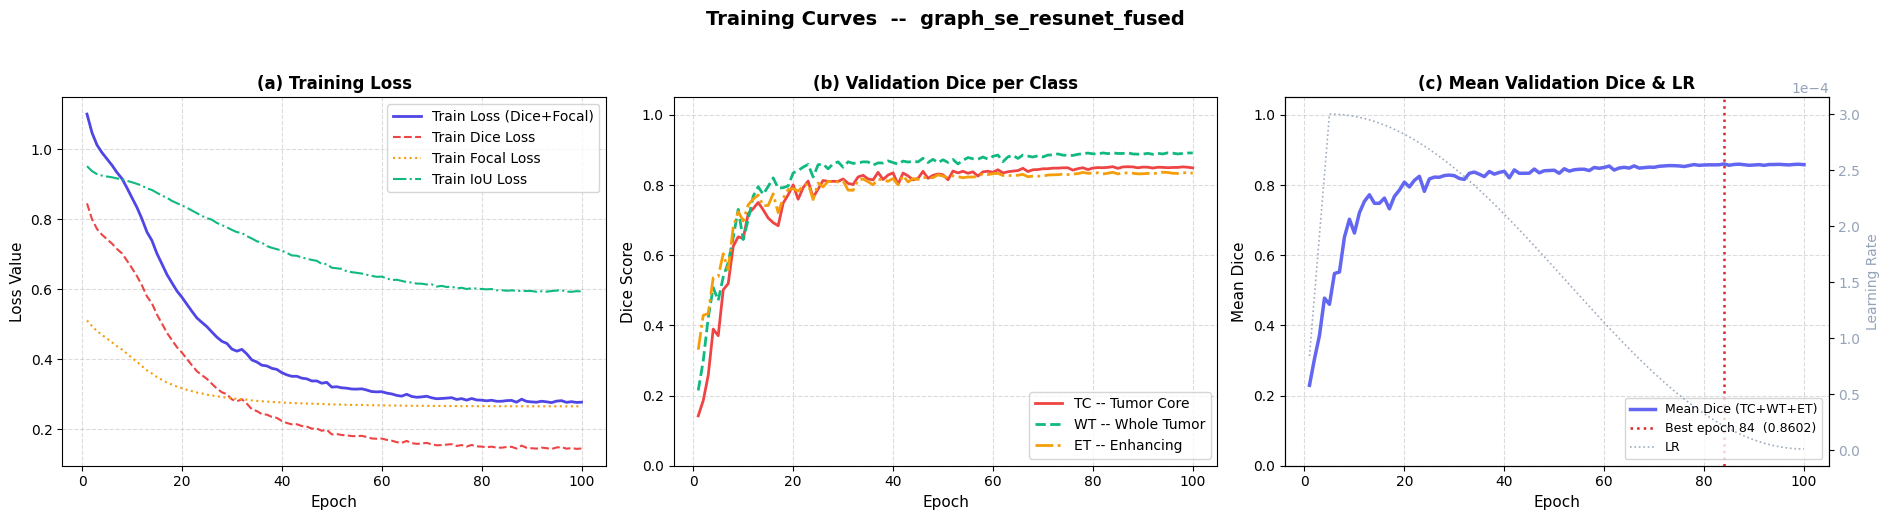

Curves saved -> /kaggle/working/graph_se_resunet_fused_curves.png


In [30]:
# ============================================================
# SECTION 8 -- Training & Validation Curves
# ============================================================

val_epochs = list(range(VAL_INTERVAL, len(history['train_loss']) + 1, VAL_INTERVAL))

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle(
    f"Training Curves  --  {MODEL_NAME}",
    fontsize=14, fontweight="bold", y=1.03
)

# (a) Training Loss

ax = axes[0]
ax.plot(
    range(1, len(history['train_loss']) + 1), history['train_loss'],
    color="#4f46e5", lw=2.0, label="Train Loss (Dice+Focal)"
)
if "train_dice" in history and len(history["train_dice"]) > 0:
    ax.plot(
        range(1, len(history['train_dice']) + 1), history['train_dice'],
        color="#ef4444", lw=1.5, linestyle="--", label="Train Dice Loss"
    )
if "train_focal" in history and len(history["train_focal"]) > 0:
    ax.plot(
        range(1, len(history['train_focal']) + 1), history['train_focal'],
        color="#f59e0b", lw=1.5, linestyle=":", label="Train Focal Loss"
    )
if "train_iou" in history and len(history["train_iou"]) > 0:
    ax.plot(
        range(1, len(history['train_iou']) + 1), history['train_iou'],
        color="#10b981", lw=1.5, linestyle="-.", label="Train IoU Loss"
    )
    
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Loss Value", fontsize=11)
ax.set_title("(a) Training Loss", fontweight="bold", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.45)
ax.legend(fontsize=10)

# (b) Per-class Validation Dice
ax = axes[1]
_class_styles = [
    ("val_tc", "TC -- Tumor Core",   "#ef4444", "-"),
    ("val_wt", "WT -- Whole Tumor",  "#10b981", "--"),
    ("val_et", "ET -- Enhancing",    "#f59e0b", "-."),
]
for key, label, color, ls in _class_styles:
    ax.plot(val_epochs, history[key], color=color, lw=2.0, linestyle=ls, label=label)
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Dice Score", fontsize=11)
ax.set_title("(b) Validation Dice per Class", fontweight="bold", fontsize=12)
ax.set_ylim(0.0, 1.05)
ax.grid(True, linestyle="--", alpha=0.45)
ax.legend(fontsize=10)

# (c) Mean Dice + LR
ax = axes[2]
ax.plot(
    val_epochs, history['val_mean'],
    color="#6366f1", lw=2.5, label="Mean Dice (TC+WT+ET)"
)
ax.axvline(
    best_epoch, color="#dc2626", linestyle=":", lw=1.8,
    label=f"Best epoch {best_epoch}  ({best_dice:.4f})"
)
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Mean Dice", fontsize=11)
ax.set_title("(c) Mean Validation Dice & LR", fontweight="bold", fontsize=12)
ax.set_ylim(0.0, 1.05)
ax.grid(True, linestyle="--", alpha=0.45)

ax2 = ax.twinx()
ax2.plot(
    range(1, len(history['train_loss']) + 1), history['lr'],
    color="#94a3b8", lw=1.2, linestyle=":", alpha=0.9, label="LR"
)
ax2.set_ylabel("Learning Rate", color="#94a3b8", fontsize=10)
ax2.tick_params(axis="y", labelcolor="#94a3b8")
ax2.ticklabel_format(style="sci", axis="y", scilimits=(-4, -4))

lines1, lbs1 = ax.get_legend_handles_labels()
lines2, lbs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, lbs1 + lbs2, fontsize=9, loc="lower right")

plt.tight_layout()
_curve_path = f"/kaggle/working/{MODEL_NAME}_curves.png"
plt.savefig(_curve_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Curves saved -> {_curve_path}")

---
## Section 9 · Inference & Slice Visualization

1. Loads the best checkpoint from `SAVE_PATH`.
2. Runs `sliding_window_inference` on the first validation sample.
3. Displays a 3×4 grid:
   - **Row 0** — four input modalities (T1, T2, T1ce, FLAIR)
   - **Row 1** — ground-truth overlays for TC / WT / ET + Dice score table
   - **Row 2** — predicted overlays for TC / WT / ET + qualitative notes

In [ ]:
# ============================================================
# SECTION 9 — Inference & Slice Visualization
# ============================================================

# ── 9.1 Load best checkpoint ─────────────────────────────────────────────────
checkpoint = torch.load(SAVE_PATH)
model.load_state_dict(checkpoint["model"])
model.eval()
print(f"Loaded best checkpoint  (ep {best_epoch},  mean Dice {best_dice:.4f})")
print(f"Source : {SAVE_PATH}")

# ── 9.2 Run sliding-window inference ─────────────────────────────────────────
predictor = _get_sw_predictor(model, MODEL_NAME, DEVICE)

import random

# Convert loader to a list of batches and pick one at random
val_batch = random.choice(list(val_loader))

#val_batch = next(iter(val_loader))
val_img   = val_batch["image"].to(DEVICE)   # (1, 4, H, W, D)
val_lbl   = val_batch["label"]               # (1, 3, H, W, D) — CPU

with torch.no_grad():
    with torch.amp.autocast(
        device_type=DEVICE.type, enabled=(VAL_AMP and DEVICE.type == "cuda")
    ):
        raw_pred = sliding_window_inference(
            val_img, ROI_SIZE, sw_batch_size=1,
            predictor=predictor, overlap=0.5,
        )

pred_bin = post_trans(raw_pred[0].cpu())   # (3, H, W, D)
gt_bin   = val_lbl[0]                       # (3, H, W, D)
img_np   = val_img[0].cpu().numpy()         # (4, H, W, D)

# ── 9.3 Per-class Dice (fast manual computation) ─────────────────────────────
def _dice(pred, gt):
    p, g = pred.float(), gt.float()
    inter = (p * g).sum()
    denom = p.sum() + g.sum()
    return (2.0 * inter / denom).item() if denom > 0 else 1.0

dice_vals = [_dice(pred_bin[ci], gt_bin[ci]) for ci in range(len(CLASS_LABELS))]

# ── 9.4 Plot ──────────────────────────────────────────────────────────────────
sl = img_np.shape[-1] // 2           # central axial slice index
MOD_NAMES = ["T1", "T2", "T1ce", "FLAIR"]
_CMAPS     = [plt.cm.Reds, plt.cm.Greens, plt.cm.Oranges]

fig, axes = plt.subplots(3, 4, figsize=(19, 14))
fig.suptitle(
    f"Inference  —  {MODEL_NAME}   (axial slice {sl}/{img_np.shape[-1]-1})",
    fontsize=14, fontweight="bold"
)

# Row 0 — Input modalities
for m, name in enumerate(MOD_NAMES):
    ax = axes[0, m]
    ax.imshow(img_np[m, :, :, sl], cmap="gray", interpolation="bilinear")
    ax.set_title(name, fontweight="bold", fontsize=12)
    ax.axis("off")

# Rows 1 & 2 — GT vs Pred overlaid on FLAIR background
flair_bg = img_np[3, :, :, sl]
for ci, (label, cmap) in enumerate(zip(CLASS_LABELS, _CMAPS)):
    gt_sl   = gt_bin[ci,   :, :, sl].float().numpy()
    pred_sl = pred_bin[ci, :, :, sl].float().numpy()

    for row, (mask, row_label) in enumerate([(gt_sl, "GT"), (pred_sl, "Pred")]):
        ax = axes[row + 1, ci]
        ax.imshow(flair_bg, cmap="gray", alpha=0.65, interpolation="bilinear")
        ax.imshow(
            np.ma.masked_where(mask == 0, mask),
            cmap=cmap, alpha=0.85, vmin=0, vmax=1
        )
        ax.set_title(
            f"{row_label} — {label}" + (f"  Dice={dice_vals[ci]:.3f}" if row == 1 else ""),
            fontweight="bold", fontsize=11
        )
        ax.axis("off")

# Rows 1 & 2, col 3 — Dice score table
for row in (1, 2):
    axes[row, 3].axis("off")

ax_tbl = axes[1, 3]
ax_tbl.axis("off")
table_rows  = [[lbl, f"{d:.4f}"] for lbl, d in zip(CLASS_LABELS, dice_vals)]
table_rows += [["Mean", f"{float(np.mean(dice_vals)):.4f}"]]
tbl = ax_tbl.table(
    cellText=table_rows,
    colLabels=["Region", "Dice"],
    cellLoc="center", loc="center",
    bbox=[0.1, 0.25, 0.8, 0.55],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(13)
# Colour the header row
for j in range(2):
    tbl[0, j].set_facecolor("#4f46e5")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
# Colour the Mean row
for j in range(2):
    tbl[len(table_rows), j].set_facecolor("#e0e7ff")
    tbl[len(table_rows), j].set_text_props(fontweight="bold")
ax_tbl.set_title("Dice Scores", fontweight="bold", fontsize=12, pad=12)

# Bottom-right: qualitative summary
ax_note = axes[2, 3]
ax_note.axis("off")
summary = (
    f"Model  : {MODEL_NAME}\n"
    f"Best ep: {best_epoch}\n"
    f"Mean Dice (val): {best_dice:.4f}\n"
    f"Slice  : {sl}/{img_np.shape[-1]-1}\n"
    "\nTC = Tumor Core\n"
    "WT = Whole Tumor\n"
    "ET = Enhancing Tumor"
)
ax_note.text(
    0.5, 0.5, summary, transform=ax_note.transAxes,
    fontsize=11, va="center", ha="center",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#f0f9ff", edgecolor="#6366f1", lw=1.5),
)

plt.tight_layout()
_inf_path = f"/kaggle/working/{MODEL_NAME}_inference.png"
plt.savefig(_inf_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Inference plot saved → {_inf_path}")

In [ ]:
import json
from IPython.display import FileLink, display

# ---- Save training history as JSON -----------------------------------------
history_path = f"/kaggle/working/{MODEL_NAME}_history.json"
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)

print(f"Model weights saved -> {SAVE_PATH}")
print(f"History saved       -> {history_path}")
print(f"Curves saved        -> {_curve_path}")
print(f"Inference saved        -> {_inf_path}")

# ---- Download links (Kaggle notebook) ---------------------------------------
display(FileLink(SAVE_PATH))
display(FileLink(history_path))
display(FileLink(_curve_path))
display(FileLink(_inf_path))

In [ ]:
# 
import time
from IPython.display import FileLink

# Setup the dynamic filename
timestamp = time.strftime("%Y%m%d_%H%M%S")
zip_name = f"{MODEL_NAME}_results_{timestamp}.zip"

# Zip the directory using the dynamic filename
!zip -r {zip_name} /kaggle/working -x "*.zip"

# Generate the download link
FileLink(zip_name)

In [ ]:
MAX_EPOCHS = 200
RESUME_TRAINING = True
CHECKPOINT_PATH = "/kaggle/working/best_model.pth"


_warmup_epochs = 5
_cosine_epochs = MAX_EPOCHS - _warmup_epochs

warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=_warmup_epochs)
cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=_cosine_epochs, eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[_warmup_epochs])


start_epoch = 1

if RESUME_TRAINING and os.path.exists(CHECKPOINT_PATH):
    print(f"Loading checkpoint: {CHECKPOINT_PATH}")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    
    model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    scheduler.load_state_dict(checkpoint["scheduler"])
    scaler.load_state_dict(checkpoint["scaler"])
    
    start_epoch = checkpoint["epoch"] + 1
    history = checkpoint["history"]
    print(f"Resuming training from epoch {start_epoch}")

    # Your existing train_one_epoch, scheduler.step(), and validate calls go here

In [ ]:
for epoch in range(start_epoch, MAX_EPOCHS + 1):
    t0 = time.time()

    # -- train ----------------------------------------------------------------

    train_loss, train_dice, train_focal, train_iou = train_one_epoch(
        model, train_loader, optimizer, loss_fn, scaler, DEVICE, MODEL_NAME, iou_fn
    )
    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(train_loss)
    history["train_dice"].append(train_dice)
    history["train_focal"].append(train_focal)
    history["train_iou"].append(train_iou)
    history["lr"].append(current_lr)
    
    # train_loss, train_iou = train_one_epoch(
    #     model, train_loader, optimizer, loss_fn, scaler, DEVICE, MODEL_NAME, iou_fn
    # )
    # scheduler.step()
    # current_lr = optimizer.param_groups[0]["lr"]
    # history["train_loss"].append(train_loss)
    # history["train_iou"].append(train_iou)
    # history["lr"].append(current_lr)

    # -- validate -------------------------------------------------------------
    if epoch % VAL_INTERVAL == 0:
        dice_scores = validate(
            model, val_loader, dice_metric, post_trans, DEVICE, MODEL_NAME, ROI_SIZE
        )
        tc, wt, et = float(dice_scores[0]), float(dice_scores[1]), float(dice_scores[2])
        mean_d = float(np.mean(dice_scores))
        del dice_scores

        history["val_tc"].append(tc)
        history["val_wt"].append(wt)
        history["val_et"].append(et)
        history["val_mean"].append(mean_d)

        if mean_d > best_dice:
            best_dice, best_epoch = mean_d, epoch
            #torch.save(model.state_dict(), SAVE_PATH)
            torch.save({
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "scaler": scaler.state_dict(),
                "epoch": epoch,
                "history": history,
            }, SAVE_PATH)

        elapsed = time.time() - t0

        


        print(
            f"Epoch {epoch:3d}/{MAX_EPOCHS}  lr={current_lr:.2e}  t={elapsed:.1f}s----------------------------------------\n"
            #f"loss={train_loss:.4f}  iou={train_iou:.4f}  "
            f"Losses : loss={train_loss:.4f}  dice={train_dice:.4f}  focal={train_focal:.4f}  iou={train_iou:.4f}\n"
            f"Metrics: TC={tc:.4f}  WT={wt:.4f}  ET={et:.4f}  mean={mean_d:.4f}  [best {best_dice:.4f} @ep{best_epoch}]\n"
        )
    else:
        rich.print(f"Epoch {epoch:3d}/{MAX_EPOCHS}  loss={train_loss:.4f}  dice={train_dice:.4f}  focal={train_focal:.4f}  iou={train_iou:.4f}  lr={current_lr:.2e}  {time.time()-t0:.1f}s")

    # Keep memory housekeeping at the epoch boundary only
    gc.collect()
    torch.cuda.empty_cache()

print()
print(f"Training complete.  Best mean Dice: {best_dice:.4f}  @ epoch {best_epoch}")
print(f"Best weights saved -> {SAVE_PATH}")

In [ ]:
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric, HausdorffDistanceMetric, ConfusionMatrixMetric
from monai.data import decollate_batch

model.load_state_dict(checkpoint["model"])
model.eval()
predictor = _get_sw_predictor(model, MODEL_NAME, DEVICE)

dice_pp = DiceMetric(include_background=True, reduction="none", get_not_nans=False)
hd95_pp = HausdorffDistanceMetric(include_background=True, percentile=95, reduction="none", get_not_nans=False)
sens_pp = ConfusionMatrixMetric(include_background=True, metric_name="sensitivity", reduction="none", get_not_nans=False)
spec_pp = ConfusionMatrixMetric(include_background=True, metric_name="specificity", reduction="none", get_not_nans=False)

records = []
best_case, best_case_score = None, -1
worst_case, worst_case_score = None, 2

with torch.no_grad():
    for case_idx, batch in enumerate(val_loader):
        x = batch["image"].to(DEVICE, non_blocking=True)
        y = batch["label"].to(DEVICE, non_blocking=True)

        with torch.amp.autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
            preds = sliding_window_inference(x, ROI_SIZE, sw_batch_size=1, predictor=predictor, overlap=0.5)

        preds_bin = [post_trans(p) for p in decollate_batch(preds)]
        labels = decollate_batch(y)

        dice_pp(y_pred=preds_bin, y=labels)
        hd95_pp(y_pred=preds_bin, y=labels)
        sens_pp(y_pred=preds_bin, y=labels)
        spec_pp(y_pred=preds_bin, y=labels)

        d = dice_pp.aggregate()
        h = hd95_pp.aggregate()
        sn = sens_pp.aggregate()[0]
        sp = spec_pp.aggregate()[0]
        dice_pp.reset(); hd95_pp.reset(); sens_pp.reset(); spec_pp.reset()

        row = {"case_idx": case_idx}
        for ci, lbl in enumerate(CLASS_LABELS):
            row[f"dice_{lbl}"] = float(d[0, ci])
            row[f"hd95_{lbl}"] = float(h[0, ci])
            row[f"sens_{lbl}"] = float(sn[0, ci])
            row[f"spec_{lbl}"] = float(sp[0, ci])
        row["mean_dice"] = float(np.mean([row[f"dice_{c}"] for c in CLASS_LABELS]))
        row["mean_hd95"] = float(np.mean([row[f"hd95_{c}"] for c in CLASS_LABELS]))
        row["mean_sens"] = float(np.mean([row[f"sens_{c}"] for c in CLASS_LABELS]))
        row["mean_spec"] = float(np.mean([row[f"spec_{c}"] for c in CLASS_LABELS]))
        records.append(row)

        if row["mean_dice"] > best_case_score:
            best_case_score, best_case = row["mean_dice"], (case_idx, x.cpu(), y.cpu(), preds_bin)
        if row["mean_dice"] < worst_case_score:
            worst_case_score, worst_case = row["mean_dice"], (case_idx, x.cpu(), y.cpu(), preds_bin)

        del x, y, preds, preds_bin, labels, d, h, sn, sp

df = pd.DataFrame(records)
csv_path = os.path.join(OUTPUT_DIR, f"{MODEL_NAME}_per_patient_scores.csv")
df.to_csv(csv_path, index=False)
print(f"Saved -> {csv_path}")
df.describe()